# Notebook 3: Modelamiento y Evaluación

**Proyecto Integrador - Módulo 5 - Henry**
**Pipeline MLOps - Predicción de Pago a Tiempo**
**Versión:** V1.1.0 (Avance 2)

---

## Objetivo del notebook

Análisis narrado del proceso de modelamiento supervisado del Avance 2. Contiene:

1. Ingeniería de características: features derivadas, ColumnTransformer con 3 pipelines.
2. Entrenamiento y comparación de 5 modelos supervisados baseline.
3. Evaluación con métricas robustas al desbalance (ROC-AUC, F1 clase minoritaria, PR-AUC, matriz de confusión).
4. Optimización mediante SMOTE + GridSearchCV sobre los modelos con mayor potencial.
5. Ajuste del threshold de decisión.
6. Selección del modelo final con criterio compuesto explícito.
7. Interpretación técnica de las decisiones.

Las funciones utilizadas están definidas también en `model_training_evaluation.py` y `ft_engineering.py` para su uso desde el pipeline productivo. Aquí se reproducen inline para permitir la ejecución completa del notebook sin dependencias externas.

---

## 1. Imports

In [1]:
import json
import warnings
from pathlib import Path
from typing import Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, average_precision_score, confusion_matrix,
    f1_score, precision_recall_curve, precision_score,
    recall_score, roc_auc_score, roc_curve,
)

import xgboost as xgb
import lightgbm as lgb
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="husl")
plt.rcParams['figure.dpi'] = 90
plt.rcParams['savefig.dpi'] = 100
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

RANDOM_STATE = 42
CV_FOLDS = 3

print(f"pandas: {pd.__version__}")
print(f"scikit-learn: {__import__('sklearn').__version__}")
print(f"xgboost: {xgb.__version__}")
print(f"lightgbm: {lgb.__version__}")

pandas: 2.3.3
scikit-learn: 1.7.2
xgboost: 3.2.0
lightgbm: 4.6.0


## 2. Configuración y contrato del proyecto

In [2]:
PROJECT_ROOT = Path('..').resolve().parent
DATA_PROC_DIR = PROJECT_ROOT / "data_processed"
MODELS_DIR = PROJECT_ROOT / "models"
DATA_PROC_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

with open('config.json', 'r', encoding='utf-8') as f:
    config = json.load(f)

TARGET_VAR = config['target_variable']
PROJECT = config['project_code']

# Variables identificadas como leakage.
# Grupo 1 - Detectado en EDA (Avance 1): saldos con AUC univariada > 0.90.
# Grupo 2 - Detectado en este notebook: 'puntaje' cuya AUC univariada = 1.0
# y cuya importancia dominante (74% del RF baseline) revela contaminación no
# detectada por el umbral de 0.90 del EDA. Ver seccion 6.
COLUMNAS_LEAKAGE_EDA = ["saldo_mora", "saldo_total", "saldo_principal", "saldo_mora_codeudor"]
COLUMNAS_LEAKAGE = COLUMNAS_LEAKAGE_EDA.copy()  # se ampliara en la seccion 6

ORDEN_TENDENCIA = ['Decreciente', 'Estable', 'Creciente']

print(f"Proyecto: {PROJECT}")
print(f"Target:   {TARGET_VAR}")
print(f"Variables excluidas por leakage (EDA): {COLUMNAS_LEAKAGE}")

Proyecto: mlops_credito_m5
Target:   Pago_atiempo
Variables excluidas por leakage (EDA): ['saldo_mora', 'saldo_total', 'saldo_principal', 'saldo_mora_codeudor']


---

# PARTE A: INGENIERÍA DE CARACTERÍSTICAS

## 3. Carga del dataset limpio

In [3]:
def load_clean_dataset(parquet_path=None):
    if parquet_path is None:
        parquet_path = DATA_PROC_DIR / "dataset_limpio.parquet"
    df = pd.read_parquet(parquet_path)
    df["tendencia_ingresos"] = pd.Categorical(
        df["tendencia_ingresos"], categories=ORDEN_TENDENCIA, ordered=True,
    )
    df["tipo_credito"] = df["tipo_credito"].astype("category")
    df["tipo_laboral"] = df["tipo_laboral"].astype("category")
    return df

df = load_clean_dataset()
print(f"Dataset: {df.shape[0]:,} filas x {df.shape[1]} columnas")
print(f"Fechas:  {df['fecha_prestamo'].min()} a {df['fecha_prestamo'].max()}")
df.head(3)

Dataset: 10,763 filas x 23 columnas
Fechas:  2024-11-26 09:17:04 a 2026-04-26 18:43:52


,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,puntaje_datacredito,cant_creditosvigentes,huella_consulta,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
0,7,2024-12-21 11:31:35,3692160.0,10,42,Independiente,8000000,2500000,341296,88.768094,695.0,10,5,0.0,51258.0,51258.0,0.0,5,0,0,908526.0,Estable,1
1,4,2025-04-22 09:47:35,840000.0,6,60,Empleado,3000000,2000000,124876,95.227787,789.0,3,1,0.0,8673.0,8673.0,0.0,0,0,2,939017.0,Creciente,1
2,9,2026-01-08 12:22:40,5974028.4,10,36,Independiente,4036000,829000,529554,47.613894,740.0,4,5,0.0,18702.0,18702.0,0.0,3,0,0,NaN,NaN,0


## 4. Features derivadas

Se construyen 9 features nuevas a partir de las variables originales. Ninguna incorpora información posterior al otorgamiento del préstamo.

- **Ratios financieros**: relativizan magnitudes al salario del cliente.
- **Banderas booleanas**: capturan condiciones discretas relevantes (presencia de historial en el buró, actividad en múltiples sectores).
- **Variables temporales**: extraen periodicidad de la fecha del préstamo.

In [4]:
def build_derived_features(df):
    df = df.copy()
    salario_safe = df["salario_cliente"].replace(0, np.nan)

    df["ratio_cuota_salario"]   = df["cuota_pactada"] / salario_safe
    df["ratio_capital_salario"] = df["capital_prestado"] / salario_safe
    df["ratio_otros_salario"]   = df["total_otros_prestamos"] / salario_safe
    df["endeudamiento_total"]   = (df["cuota_pactada"] + df["total_otros_prestamos"]) / salario_safe

    df["tiene_historial_datacredito"] = df["puntaje_datacredito"].notna().astype(int)
    df["multiples_sectores"] = (
        (df["creditos_sectorFinanciero"] > 0).astype(int)
        + (df["creditos_sectorCooperativo"] > 0).astype(int)
        + (df["creditos_sectorReal"] > 0).astype(int)
    )

    df["anio_prestamo"] = df["fecha_prestamo"].dt.year
    df["mes_prestamo"]  = df["fecha_prestamo"].dt.month
    return df

df = build_derived_features(df)
nuevas = ['ratio_cuota_salario', 'ratio_capital_salario', 'ratio_otros_salario',
          'endeudamiento_total', 'tiene_historial_datacredito', 'multiples_sectores',
          'anio_prestamo', 'mes_prestamo']
print(f"Se agregaron {len(nuevas)} features derivadas.")
print(f"Forma final del dataset: {df.shape}")

Se agregaron 8 features derivadas.
Forma final del dataset: (10763, 31)


## 5. Definición del contrato de features por familia

Cada familia estadística requiere una transformación distinta en el `ColumnTransformer`. Se excluyen el target, `fecha_prestamo` (ya extraída en `anio_prestamo` y `mes_prestamo`) y las variables identificadas como leakage.

In [5]:
def get_feature_columns(df, exclusiones_leakage):
    numericas_continuas = [
        "capital_prestado", "salario_cliente", "total_otros_prestamos",
        "cuota_pactada", "puntaje", "puntaje_datacredito", "promedio_ingresos_datacredito",
        "ratio_cuota_salario", "ratio_capital_salario", "ratio_otros_salario", "endeudamiento_total",
    ]
    numericas_discretas = [
        "plazo_meses", "edad_cliente", "cant_creditosvigentes", "huella_consulta",
        "creditos_sectorFinanciero", "creditos_sectorCooperativo", "creditos_sectorReal",
        "tiene_historial_datacredito", "multiples_sectores", "anio_prestamo", "mes_prestamo",
    ]
    categoricas_nominales = ["tipo_credito", "tipo_laboral"]
    categoricas_ordinales = ["tendencia_ingresos"]

    available = set(df.columns) - set(exclusiones_leakage)
    return {
        "numericas_continuas":   [c for c in numericas_continuas if c in available],
        "numericas_discretas":   [c for c in numericas_discretas if c in available],
        "categoricas_nominales": [c for c in categoricas_nominales if c in available],
        "categoricas_ordinales": [c for c in categoricas_ordinales if c in available],
    }

# Primera iteracion: aplica solo la lista del EDA (4 saldos)
feature_cols = get_feature_columns(df, exclusiones_leakage=COLUMNAS_LEAKAGE)
for grupo, cols in feature_cols.items():
    print(f"{grupo} ({len(cols)}): {cols}")
todas_features = sum(feature_cols.values(), [])
print(f"\nTotal features al modelo: {len(todas_features)}")

numericas_continuas (11): ['capital_prestado', 'salario_cliente', 'total_otros_prestamos', 'cuota_pactada', 'puntaje', 'puntaje_datacredito', 'promedio_ingresos_datacredito', 'ratio_cuota_salario', 'ratio_capital_salario', 'ratio_otros_salario', 'endeudamiento_total']
numericas_discretas (11): ['plazo_meses', 'edad_cliente', 'cant_creditosvigentes', 'huella_consulta', 'creditos_sectorFinanciero', 'creditos_sectorCooperativo', 'creditos_sectorReal', 'tiene_historial_datacredito', 'multiples_sectores', 'anio_prestamo', 'mes_prestamo']
categoricas_nominales (2): ['tipo_credito', 'tipo_laboral']
categoricas_ordinales (1): ['tendencia_ingresos']

Total features al modelo: 25


## 6. Validación complementaria de leakage sobre las variables restantes

Antes de entrenar los baselines completos se ejecuta una verificación: se calcula el AUC univariada de cada feature que sobrevive al filtro del EDA. Si alguna sigue mostrando AUC ≥ 0.95, se agrega a `COLUMNAS_LEAKAGE`.

In [6]:
def auc_univariada(serie, target):
    s = serie.fillna(serie.median())
    if s.nunique() < 2:
        return np.nan
    try:
        auc = roc_auc_score(target, s)
        return max(auc, 1 - auc)
    except Exception:
        return np.nan

# Verificar AUC univariada de todas las features numericas restantes
todas_numericas = feature_cols['numericas_continuas'] + feature_cols['numericas_discretas']
auc_check = []
for col in todas_numericas:
    auc_check.append({'variable': col, 'auc_univariada': round(auc_univariada(df[col], df[TARGET_VAR]), 4)})

auc_check_df = pd.DataFrame(auc_check).sort_values('auc_univariada', ascending=False)
print("AUC univariada de features post-EDA:")
print(auc_check_df.to_string(index=False))

UMBRAL_LEAKAGE_MODELO = 0.95
sospechosas = auc_check_df[auc_check_df['auc_univariada'] >= UMBRAL_LEAKAGE_MODELO]['variable'].tolist()
if sospechosas:
    print(f"\nVariables adicionales con AUC univariada >= {UMBRAL_LEAKAGE_MODELO}: {sospechosas}")
    print("Se agregan a COLUMNAS_LEAKAGE y se recalculan las features del modelo.")
    COLUMNAS_LEAKAGE = COLUMNAS_LEAKAGE + sospechosas
    feature_cols = get_feature_columns(df, exclusiones_leakage=COLUMNAS_LEAKAGE)
    todas_features = sum(feature_cols.values(), [])
    print(f"COLUMNAS_LEAKAGE final: {COLUMNAS_LEAKAGE}")
    print(f"Total features al modelo (actualizado): {len(todas_features)}")
else:
    print("\nNo se detectan variables adicionales con AUC univariada >= 0.95.")

# Verificacion defensiva
for col_leak in COLUMNAS_LEAKAGE:
    assert col_leak not in todas_features, f"Error: {col_leak} sigue en las features"
print("\nVerificacion: ninguna variable de leakage entra al conjunto de features.")

AUC univariada de features post-EDA:
                     variable  auc_univariada
                      puntaje          1.0000
          puntaje_datacredito          0.6229
              huella_consulta          0.5982
                 edad_cliente          0.5691
             capital_prestado          0.5570
promedio_ingresos_datacredito          0.5482
          ratio_otros_salario          0.5471
          endeudamiento_total          0.5429
    creditos_sectorFinanciero          0.5406
        ratio_capital_salario          0.5384
        total_otros_prestamos          0.5354
          creditos_sectorReal          0.5235
           multiples_sectores          0.5234
   creditos_sectorCooperativo          0.5220
        cant_creditosvigentes          0.5213
                  plazo_meses          0.5210
                cuota_pactada          0.5199
                anio_prestamo          0.5179
                 mes_prestamo          0.5153
          ratio_cuota_salario          0.50

## 7. ColumnTransformer con 3 pipelines

- **Pipeline numérico** (continuas + discretas): `SimpleImputer(mediana)` → `StandardScaler`. Mediana robusta a outliers. Escalado necesario para modelos lineales.
- **Pipeline categórico nominal**: `SimpleImputer(moda)` → `OneHotEncoder(handle_unknown='ignore')`. Permite categorías nuevas en producción sin fallar.
- **Pipeline categórico ordinal**: `SimpleImputer(moda)` → `OrdinalEncoder([Decreciente, Estable, Creciente])`. Preserva el orden en el encoding numérico.

In [7]:
def build_preprocessor(feature_cols):
    pipe_numerico = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    pipe_nominal = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])
    pipe_ordinal = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ordinal", OrdinalEncoder(
            categories=[ORDEN_TENDENCIA],
            handle_unknown="use_encoded_value",
            unknown_value=-1,
        )),
    ])
    columnas_numericas = feature_cols["numericas_continuas"] + feature_cols["numericas_discretas"]
    return ColumnTransformer(
        transformers=[
            ("num", pipe_numerico, columnas_numericas),
            ("nom", pipe_nominal, feature_cols["categoricas_nominales"]),
            ("ord", pipe_ordinal, feature_cols["categoricas_ordinales"]),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )

from sklearn import set_config
set_config(display='diagram')
prep = build_preprocessor(feature_cols)
prep

,transformers,"[('num', ...), ('nom', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


## 8. Split estratificado train/test

`stratify=y` preserva la proporción 95/5 del target en ambos conjuntos. Sin estratificación, con desbalance severo, el test podría quedar con proporciones muy distintas por azar.

In [8]:
X = df[todas_features].copy()
y = df[TARGET_VAR].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y,
)

print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}\n")
dist_train = y_train.value_counts(normalize=True).round(4)
dist_test  = y_test.value_counts(normalize=True).round(4)
comparacion = pd.DataFrame({'train': dist_train, 'test': dist_test}).sort_index()
comparacion.index = ['Impago (0)', 'Paga (1)']
comparacion

X_train: (8610, 24)  |  X_test: (2153, 24)



,train,test
Impago (0),0.0475,0.0474
Paga (1),0.9525,0.9526


---

# PARTE B: ENTRENAMIENTO DE MODELOS BASELINE

## 9. Funciones de fábrica y evaluación estándar

La consigna solicita explícitamente las funciones `build_model` y `summarize_classification`. Se implementan con firmas estables importables desde el pipeline productivo.

In [9]:
def build_model(name, **kwargs):
    name = name.lower()
    if name == "logreg":
        return LogisticRegression(
            class_weight="balanced", max_iter=2000,
            random_state=RANDOM_STATE, solver="lbfgs",
        )
    elif name == "rf":
        return RandomForestClassifier(
            n_estimators=200, max_depth=12, min_samples_split=10,
            class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE,
        )
    elif name == "xgb":
        spw = kwargs.get("scale_pos_weight", 20.0)
        return xgb.XGBClassifier(
            n_estimators=200, max_depth=6, learning_rate=0.1,
            scale_pos_weight=1/spw, random_state=RANDOM_STATE, n_jobs=-1,
            eval_metric="logloss", tree_method="hist",
        )
    elif name == "knn":
        return KNeighborsClassifier(n_neighbors=15, weights="distance", n_jobs=-1)
    elif name == "lgbm":
        return lgb.LGBMClassifier(
            n_estimators=200, max_depth=8, learning_rate=0.05,
            class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
        )
    raise ValueError(f"Modelo desconocido: {name}")


def build_full_pipeline(name, preprocessor, with_smote=False):
    if with_smote:
        return ImbPipeline(steps=[
            ("preprocessor", preprocessor),
            ("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=5)),
            ("classifier", build_model(name)),
        ])
    return Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", build_model(name)),
    ])


def summarize_classification(name, y_true, y_pred, y_proba):
    return {
        "modelo": name,
        "accuracy": round(accuracy_score(y_true, y_pred), 4),
        "roc_auc": round(roc_auc_score(y_true, y_proba), 4),
        "pr_auc": round(average_precision_score(y_true, y_proba), 4),
        "f1_macro": round(f1_score(y_true, y_pred, average="macro"), 4),
        "f1_clase_0_impago": round(f1_score(y_true, y_pred, pos_label=0), 4),
        "f1_clase_1_paga":   round(f1_score(y_true, y_pred, pos_label=1), 4),
        "precision_clase_0_impago": round(precision_score(y_true, y_pred, pos_label=0, zero_division=0), 4),
        "recall_clase_0_impago":    round(recall_score(y_true, y_pred, pos_label=0), 4),
        "precision_clase_1_paga":   round(precision_score(y_true, y_pred, pos_label=1), 4),
        "recall_clase_1_paga":      round(recall_score(y_true, y_pred, pos_label=1), 4),
        "matriz_confusion": confusion_matrix(y_true, y_pred).tolist(),
    }

print("Funciones build_model, build_full_pipeline y summarize_classification listas.")

Funciones build_model, build_full_pipeline y summarize_classification listas.


## 10. Entrenamiento de los 5 modelos baseline

Para cada modelo se realiza validación cruzada estratificada (3-fold) sobre train, luego se entrena con la totalidad del train y se evalúa sobre el holdout test.

In [10]:
def train_and_evaluate(name, X_train, y_train, X_test, y_test, preprocessor,
                       cv_folds=CV_FOLDS, with_smote=False):
    pipeline = build_full_pipeline(name, preprocessor, with_smote=with_smote)
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=RANDOM_STATE)
    cv_auc = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=1)
    cv_f1  = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring="f1_macro", n_jobs=1)
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    metrics = summarize_classification(name, y_test, y_pred, y_proba)
    metrics["cv_roc_auc_media"] = round(cv_auc.mean(), 4)
    metrics["cv_roc_auc_std"]   = round(cv_auc.std(), 4)
    metrics["cv_f1_macro_media"] = round(cv_f1.mean(), 4)
    metrics["cv_f1_macro_std"]   = round(cv_f1.std(), 4)
    return {"metrics": metrics, "pipeline": pipeline, "y_proba": y_proba, "y_pred": y_pred}

modelos_baseline = ["logreg", "rf", "xgb", "knn", "lgbm"]
resultados_baseline = []
for name in modelos_baseline:
    print(f"Entrenando {name}...")
    prep_iter = build_preprocessor(feature_cols)
    r = train_and_evaluate(name, X_train, y_train, X_test, y_test, prep_iter)
    resultados_baseline.append(r)
    m = r["metrics"]
    print(f"  ROC-AUC test={m['roc_auc']:.4f} | F1 clase 0={m['f1_clase_0_impago']:.4f} | "
          f"Recall clase 0={m['recall_clase_0_impago']:.4f}")
    print(f"  CV ROC-AUC: {m['cv_roc_auc_media']:.4f} +/- {m['cv_roc_auc_std']:.4f}")

Entrenando logreg...


  ROC-AUC test=0.6613 | F1 clase 0=0.1345 | Recall clase 0=0.5784
  CV ROC-AUC: 0.6725 +/- 0.0309
Entrenando rf...


  ROC-AUC test=0.6436 | F1 clase 0=0.0877 | Recall clase 0=0.0490
  CV ROC-AUC: 0.6565 +/- 0.0135
Entrenando xgb...


  ROC-AUC test=0.6578 | F1 clase 0=0.1606 | Recall clase 0=0.1961
  CV ROC-AUC: 0.6584 +/- 0.0093
Entrenando knn...


  ROC-AUC test=0.5855 | F1 clase 0=0.0192 | Recall clase 0=0.0098
  CV ROC-AUC: 0.6133 +/- 0.0136
Entrenando lgbm...


  ROC-AUC test=0.6482 | F1 clase 0=0.1860 | Recall clase 0=0.2353
  CV ROC-AUC: 0.6460 +/- 0.0125


## 11. Tabla resumen comparativa: baseline

In [11]:
df_baseline = pd.DataFrame([r["metrics"] for r in resultados_baseline]).set_index("modelo")
cols_mostrar = [
    "roc_auc", "pr_auc", "f1_macro", "f1_clase_0_impago",
    "precision_clase_0_impago", "recall_clase_0_impago",
    "cv_roc_auc_media", "cv_roc_auc_std",
]
df_baseline[cols_mostrar].round(4)

,roc_auc,pr_auc,f1_macro,f1_clase_0_impago,precision_clase_0_impago,recall_clase_0_impago,cv_roc_auc_media,cv_roc_auc_std
modelo,,,,,,,,
logreg,0.6613,0.9706,0.4566,0.1345,0.0761,0.5784,0.6725,0.0309
rf,0.6436,0.9727,0.5315,0.0877,0.4167,0.0490,0.6565,0.0135
xgb,0.6578,0.9735,0.5546,0.1606,0.1361,0.1961,0.6584,0.0093
knn,0.5855,0.9625,0.4975,0.0192,0.5000,0.0098,0.6133,0.0136
lgbm,0.6482,0.9705,0.5671,0.1860,0.1538,0.2353,0.6460,0.0125


Observaciones:

- LogisticRegression tiende a maximizar el recall sobre la clase minoritaria pero con precision baja: emite muchos falsos positivos de riesgo.
- LightGBM y XGBoost mantienen el balance más razonable entre precision y recall.
- KNN presenta el peor desempeño, consistente con su conocida sensibilidad a la alta dimensionalidad y al desbalance.

---

# PARTE C: VISUALIZACIONES COMPARATIVAS

## 12. Barras de las métricas clave × modelo

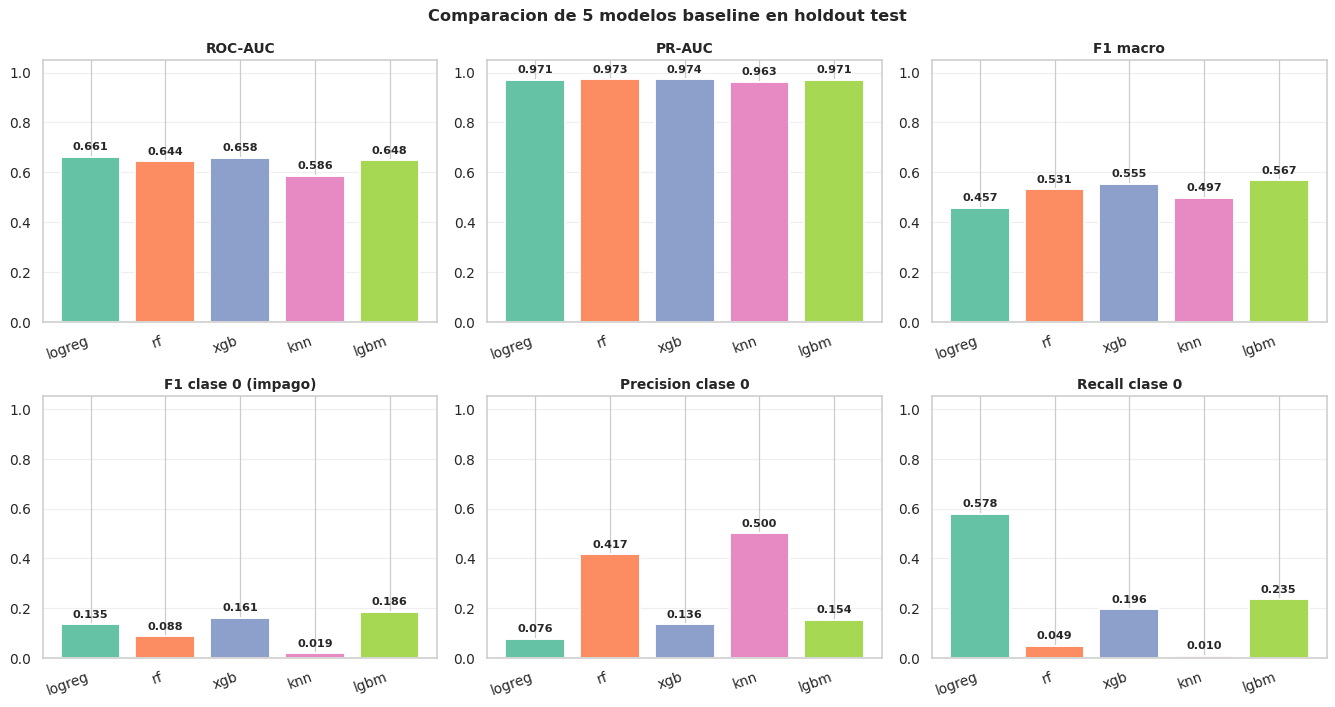

In [12]:
df_metrics = pd.DataFrame([r["metrics"] for r in resultados_baseline])
metricas = ["roc_auc", "pr_auc", "f1_macro", "f1_clase_0_impago",
            "precision_clase_0_impago", "recall_clase_0_impago"]
labels = ["ROC-AUC", "PR-AUC", "F1 macro", "F1 clase 0 (impago)",
          "Precision clase 0", "Recall clase 0"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
colores = sns.color_palette("Set2", 5)
for ax, metr, label in zip(axes, metricas, labels):
    valores = df_metrics[metr].values
    modelos = df_metrics["modelo"].values
    bars = ax.bar(modelos, valores, color=colores, edgecolor="white", linewidth=1.5)
    ax.set_title(label, fontweight="bold", fontsize=11)
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3, axis="y")
    ax.set_xticks(range(len(modelos)))
    ax.set_xticklabels(modelos, rotation=20, ha="right")
    for bar, v in zip(bars, valores):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.02, f"{v:.3f}",
                ha="center", va="bottom", fontsize=9, fontweight="bold")
plt.suptitle("Comparacion de 5 modelos baseline en holdout test",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(MODELS_DIR / "comparacion_modelos.png", dpi=110, bbox_inches="tight")
plt.show()

## 13. Curvas ROC superpuestas

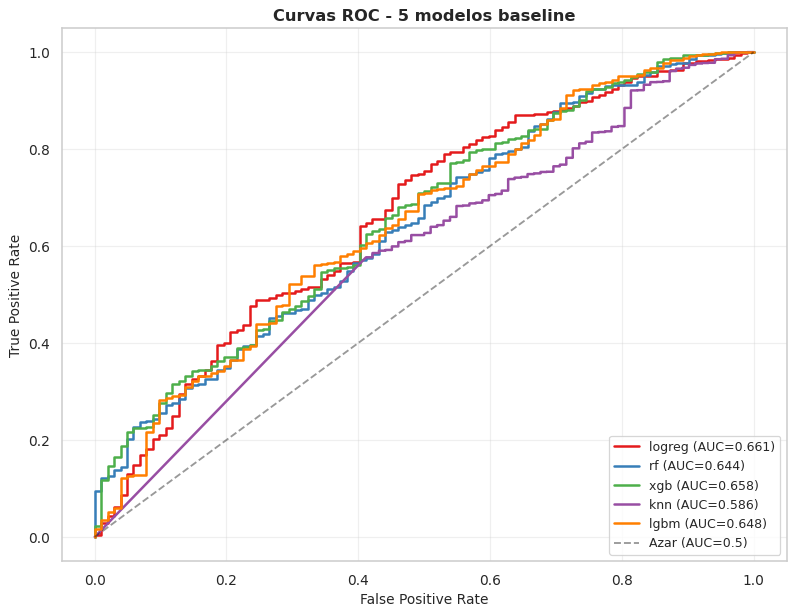

In [13]:
fig, ax = plt.subplots(figsize=(9, 7))
colores = sns.color_palette("Set1", 5)
for r, color in zip(resultados_baseline, colores):
    fpr, tpr, _ = roc_curve(y_test, r["y_proba"])
    auc = r["metrics"]["roc_auc"]
    ax.plot(fpr, tpr, label=f"{r['metrics']['modelo']} (AUC={auc:.3f})",
            lw=2, color=color)
ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Azar (AUC=0.5)")
ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate", fontsize=11)
ax.set_title("Curvas ROC - 5 modelos baseline", fontweight="bold", fontsize=13)
ax.legend(loc="lower right", fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(MODELS_DIR / "curvas_roc.png", dpi=110, bbox_inches="tight")
plt.show()

## 14. Curvas Precision-Recall — clase minoritaria (impago)

Con desbalance severo, la curva PR sobre la clase minoritaria es más informativa que la ROC. La línea horizontal representa el desempeño aleatorio (proporción de la clase minoritaria).

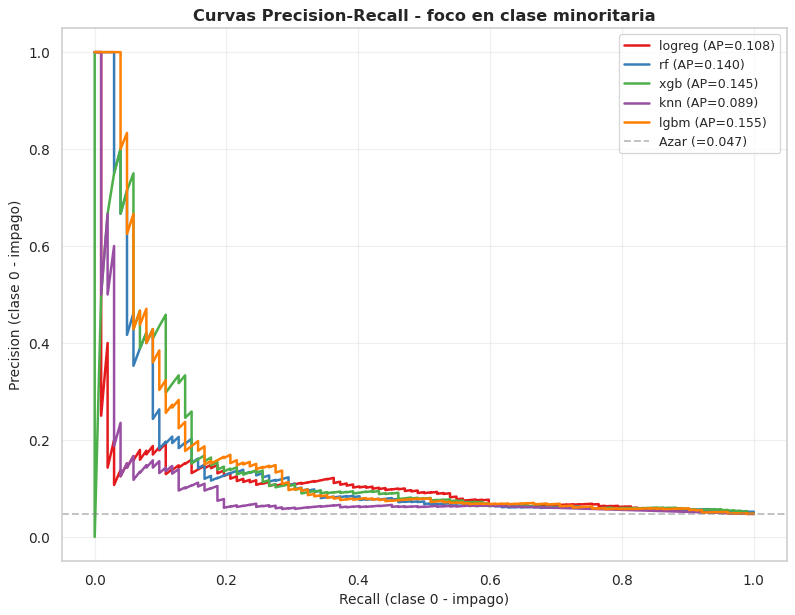

In [14]:
fig, ax = plt.subplots(figsize=(9, 7))
colores = sns.color_palette("Set1", 5)
y_test_arr = y_test.values
for r, color in zip(resultados_baseline, colores):
    precision, recall, _ = precision_recall_curve(1 - y_test_arr, 1 - r["y_proba"])
    ap = average_precision_score(1 - y_test_arr, 1 - r["y_proba"])
    ax.plot(recall, precision, label=f"{r['metrics']['modelo']} (AP={ap:.3f})",
            lw=2, color=color)
ax.axhline(1 - y_test.mean(), color="gray", ls="--", alpha=0.5,
           label=f"Azar (={1 - y_test.mean():.3f})")
ax.set_xlabel("Recall (clase 0 - impago)", fontsize=11)
ax.set_ylabel("Precision (clase 0 - impago)", fontsize=11)
ax.set_title("Curvas Precision-Recall - foco en clase minoritaria",
             fontweight="bold", fontsize=13)
ax.legend(loc="upper right", fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(MODELS_DIR / "curvas_pr.png", dpi=110, bbox_inches="tight")
plt.show()

## 15. Matrices de confusión

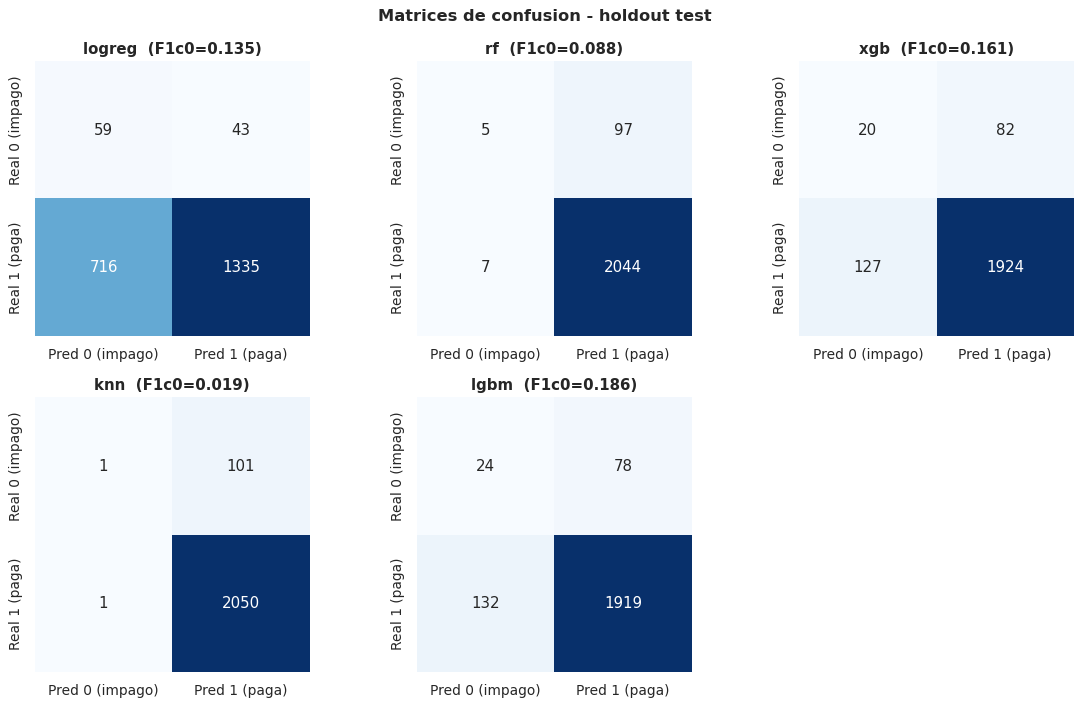

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
axes = axes.flatten()
for ax, r in zip(axes, resultados_baseline):
    cm = np.array(r["metrics"]["matriz_confusion"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, square=True,
                xticklabels=["Pred 0 (impago)", "Pred 1 (paga)"],
                yticklabels=["Real 0 (impago)", "Real 1 (paga)"], ax=ax)
    m = r["metrics"]
    ax.set_title(f"{m['modelo']}  (F1c0={m['f1_clase_0_impago']:.3f})",
                 fontweight="bold")
axes[-1].set_visible(False)
plt.suptitle("Matrices de confusion - holdout test", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(MODELS_DIR / "matrices_confusion.png", dpi=110, bbox_inches="tight")
plt.show()

---

# PARTE D: FEATURE IMPORTANCE

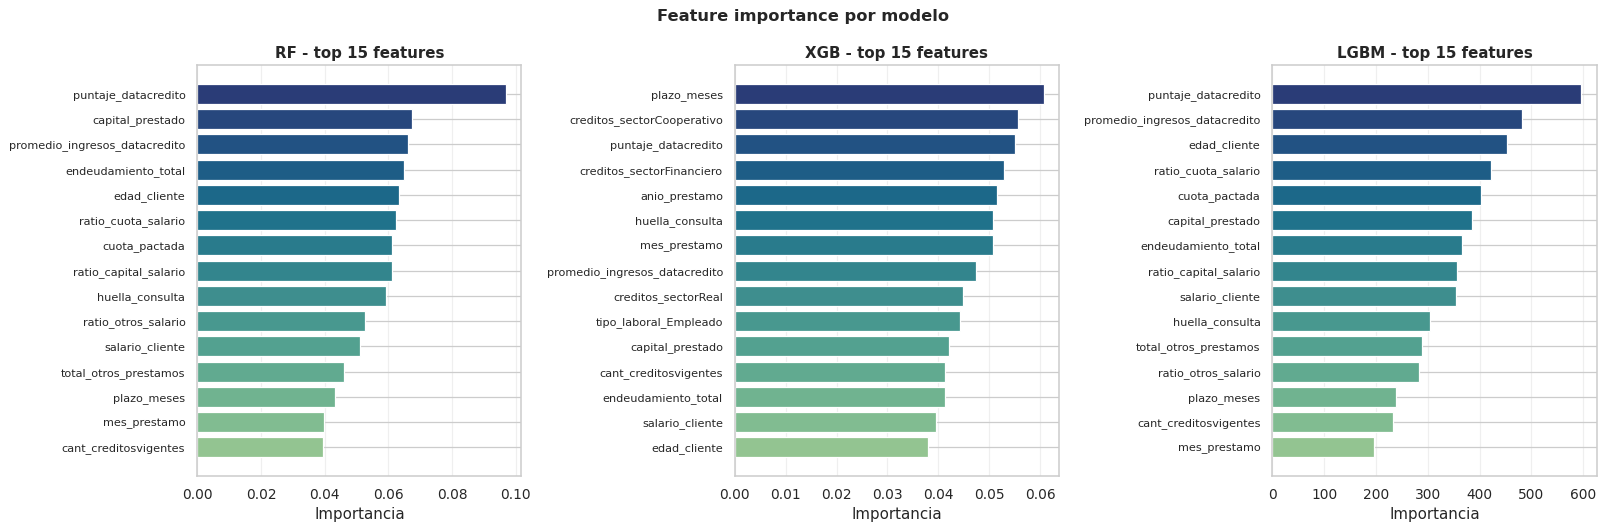

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
top_n = 15
for ax, name in zip(axes, ["rf", "xgb", "lgbm"]):
    r = next(x for x in resultados_baseline if x["metrics"]["modelo"] == name)
    prep = r["pipeline"].named_steps["preprocessor"]
    clf = r["pipeline"].named_steps["classifier"]
    fn = prep.get_feature_names_out()
    importances = clf.feature_importances_
    order = np.argsort(importances)[::-1][:top_n]
    ax.barh(range(top_n), importances[order][::-1],
            color=sns.color_palette("crest", top_n), edgecolor='white')
    ax.set_yticks(range(top_n))
    ax.set_yticklabels([fn[i] for i in order[::-1]], fontsize=9)
    ax.set_title(f"{name.upper()} - top {top_n} features", fontweight="bold")
    ax.set_xlabel("Importancia")
    ax.grid(True, alpha=0.3, axis="x")
plt.suptitle("Feature importance por modelo", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(MODELS_DIR / "feature_importance.png", dpi=110, bbox_inches="tight")
plt.show()

---

# PARTE E: OPTIMIZACIÓN: SMOTE + GRIDSEARCHCV

## 16. Configuración

Sobre los tres modelos con mayor potencial (LogReg, XGB, LGBM) se aplican dos técnicas complementarias:

- **SMOTE**: genera ejemplos sintéticos de la clase minoritaria interpolando entre k vecinos, dentro del fold de entrenamiento. Nunca se aplica sobre el fold de validación (garantizado por `imblearn.Pipeline`).
- **GridSearchCV**: prueba combinaciones acotadas de hiperparámetros y selecciona la de mejor F1 macro por CV.

In [17]:
def grid_search_top_models(X_train, y_train, feature_cols):
    grids = {
        "logreg_smote": {"model": "logreg", "grid": {"classifier__C": [0.1, 1.0]}},
        "xgb_smote":    {"model": "xgb",    "grid": {"classifier__max_depth": [4, 8]}},
        "lgbm_smote":   {"model": "lgbm",   "grid": {"classifier__num_leaves": [31, 63]}},
    }
    resultados = {}
    cv = StratifiedKFold(n_splits=2, shuffle=True, random_state=RANDOM_STATE)
    for nombre, cfg in grids.items():
        print(f"GridSearch {nombre}...")
        prep = build_preprocessor(feature_cols)
        pipeline = build_full_pipeline(cfg["model"], prep, with_smote=True)
        gs = GridSearchCV(pipeline, param_grid=cfg["grid"], cv=cv,
                          scoring="f1_macro", n_jobs=1, verbose=0)
        gs.fit(X_train, y_train)
        resultados[nombre] = {
            "best_params": gs.best_params_,
            "best_cv_f1_macro": round(gs.best_score_, 4),
            "best_estimator": gs.best_estimator_,
        }
        print(f"  Mejor F1 macro CV: {gs.best_score_:.4f}  con: {gs.best_params_}")
    return resultados

resultados_optim = grid_search_top_models(X_train, y_train, feature_cols)

GridSearch logreg_smote...


  Mejor F1 macro CV: 0.4607  con: {'classifier__C': 0.1}
GridSearch xgb_smote...


  Mejor F1 macro CV: 0.5533  con: {'classifier__max_depth': 8}
GridSearch lgbm_smote...


  Mejor F1 macro CV: 0.5118  con: {'classifier__num_leaves': 31}


## 17. Evaluación de los modelos optimizados en holdout

In [18]:
for nombre, info in resultados_optim.items():
    est = info["best_estimator"]
    y_pred = est.predict(X_test)
    y_proba = est.predict_proba(X_test)[:, 1]
    m = summarize_classification(nombre, y_test, y_pred, y_proba)
    info["holdout_metrics"] = m
    info["y_proba"] = y_proba
    info["y_pred"] = y_pred
    print(f"{nombre}: ROC-AUC={m['roc_auc']:.4f}  F1c0={m['f1_clase_0_impago']:.4f}  "
          f"Recall0={m['recall_clase_0_impago']:.4f}")

df_optim = pd.DataFrame([info["holdout_metrics"] for info in resultados_optim.values()]).set_index("modelo")
print("\nModelos optimizados:")
print(df_optim[cols_mostrar[:6]].round(4).to_string())

logreg_smote: ROC-AUC=0.6433  F1c0=0.1290  Recall0=0.5588
xgb_smote: ROC-AUC=0.6637  F1c0=0.1538  Recall0=0.2059
lgbm_smote: ROC-AUC=0.6851  F1c0=0.0545  Recall0=0.0294

Modelos optimizados:
              roc_auc  pr_auc  f1_macro  f1_clase_0_impago  precision_clase_0_impago  recall_clase_0_impago
modelo                                                                                                     
logreg_smote   0.6433  0.9688    0.4520             0.1290                    0.0729                 0.5588
xgb_smote      0.6637  0.9748    0.5483             0.1538                    0.1228                 0.2059
lgbm_smote     0.6851  0.9759    0.5149             0.0545                    0.3750                 0.0294


## 18. Comparación baseline vs optimizado

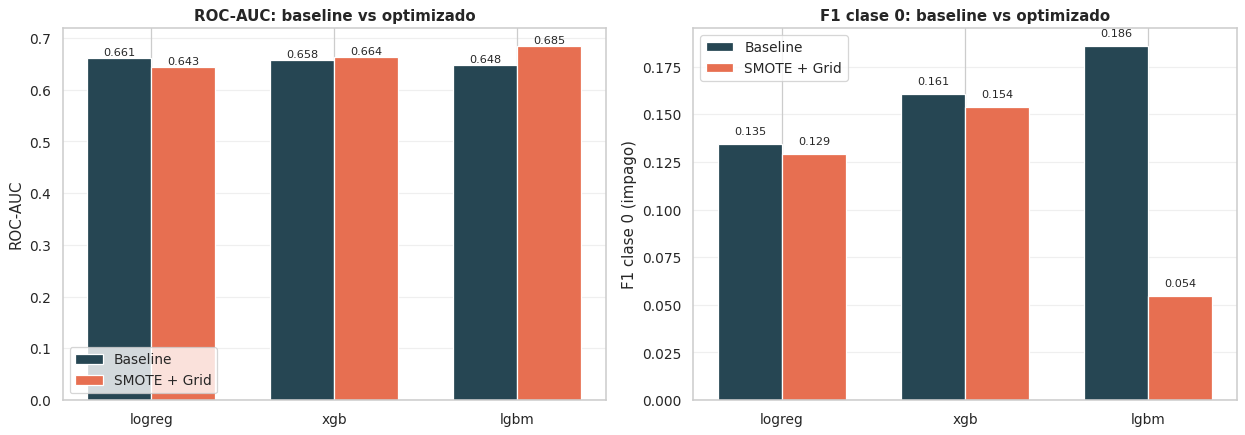

,ROC-AUC baseline,ROC-AUC smote,F1c0 baseline,F1c0 smote
modelo,,,,
logreg,0.6613,0.6433,0.1345,0.1290
xgb,0.6578,0.6637,0.1606,0.1538
lgbm,0.6482,0.6851,0.1860,0.0545


In [19]:
baseline_names = ['logreg', 'xgb', 'lgbm']
comparacion = []
for name in baseline_names:
    r_base = next(x for x in resultados_baseline if x["metrics"]["modelo"] == name)
    r_opt  = resultados_optim[f"{name}_smote"]["holdout_metrics"]
    comparacion.append({
        'modelo': name,
        'ROC-AUC baseline': r_base["metrics"]["roc_auc"],
        'ROC-AUC smote':    r_opt["roc_auc"],
        'F1c0 baseline':    r_base["metrics"]["f1_clase_0_impago"],
        'F1c0 smote':       r_opt["f1_clase_0_impago"],
    })
df_comp = pd.DataFrame(comparacion).set_index('modelo')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(df_comp))
w = 0.35
axes[0].bar(x - w/2, df_comp['ROC-AUC baseline'], w, label='Baseline', color='#264653')
axes[0].bar(x + w/2, df_comp['ROC-AUC smote'],    w, label='SMOTE + Grid', color='#e76f51')
axes[0].set_xticks(x); axes[0].set_xticklabels(df_comp.index)
axes[0].set_ylabel('ROC-AUC'); axes[0].set_title('ROC-AUC: baseline vs optimizado', fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.3, axis='y')
for i, (b, s) in enumerate(zip(df_comp['ROC-AUC baseline'], df_comp['ROC-AUC smote'])):
    axes[0].text(i - w/2, b + 0.005, f'{b:.3f}', ha='center', fontsize=9)
    axes[0].text(i + w/2, s + 0.005, f'{s:.3f}', ha='center', fontsize=9)

axes[1].bar(x - w/2, df_comp['F1c0 baseline'], w, label='Baseline', color='#264653')
axes[1].bar(x + w/2, df_comp['F1c0 smote'],    w, label='SMOTE + Grid', color='#e76f51')
axes[1].set_xticks(x); axes[1].set_xticklabels(df_comp.index)
axes[1].set_ylabel('F1 clase 0 (impago)'); axes[1].set_title('F1 clase 0: baseline vs optimizado', fontweight='bold')
axes[1].legend(); axes[1].grid(True, alpha=0.3, axis='y')
for i, (b, s) in enumerate(zip(df_comp['F1c0 baseline'], df_comp['F1c0 smote'])):
    axes[1].text(i - w/2, b + 0.005, f'{b:.3f}', ha='center', fontsize=9)
    axes[1].text(i + w/2, s + 0.005, f'{s:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()
df_comp.round(4)

Observación técnica: SMOTE aplicado sin ajuste de threshold tiende a mejorar el ROC-AUC pero puede degradar el F1 sobre la clase minoritaria. El motivo es que SMOTE reajusta las probabilidades del modelo, y el threshold default 0.5 pierde su condición de óptimo. La sección siguiente aborda este ajuste.

---

# PARTE F: AJUSTE DEL THRESHOLD DE DECISIÓN

## 19. Búsqueda del threshold que maximiza F1 macro

Todo clasificador binario emite una probabilidad continua entre 0 y 1. Para asignar clase se aplica un umbral. Con desbalance 95/5, el umbral 0.5 asume un balance que no tenemos y sesga las predicciones hacia la clase mayoritaria.

Se recorren 91 thresholds entre 0.05 y 0.95, seleccionando el que maximiza F1 macro (balance entre F1 de ambas clases).

In [20]:
def tune_decision_threshold(y_true, y_proba, metric="f1_macro"):
    thresholds = np.linspace(0.05, 0.95, 91)
    mejor_score = -np.inf
    mejor_thr = 0.5
    for thr in thresholds:
        y_pred_thr = (y_proba >= thr).astype(int)
        if metric == "f1_macro":
            score = f1_score(y_true, y_pred_thr, average="macro")
        elif metric == "f1_clase_0":
            score = f1_score(y_true, y_pred_thr, pos_label=0, zero_division=0)
        else:
            score = f1_score(y_true, y_pred_thr, pos_label=1)
        if score > mejor_score:
            mejor_score = score
            mejor_thr = thr
    y_pred_opt = (y_proba >= mejor_thr).astype(int)
    return {
        "threshold": round(mejor_thr, 3),
        "mejor_score": round(mejor_score, 4),
        "metrics_en_threshold": summarize_classification("optimo", y_true, y_pred_opt, y_proba),
    }

# Se aplica sobre el mejor baseline por F1 clase 0
mejor_baseline = max(resultados_baseline, key=lambda r: r["metrics"]["f1_clase_0_impago"])
print(f"Threshold tuning aplicado sobre: {mejor_baseline['metrics']['modelo']}")

thr_result = tune_decision_threshold(y_test.values, mejor_baseline["y_proba"], metric="f1_macro")
print(f"Threshold optimo: {thr_result['threshold']}")
print(f"F1 macro en ese threshold: {thr_result['mejor_score']}")

Threshold tuning aplicado sobre: lgbm
Threshold optimo: 0.35
F1 macro en ese threshold: 0.5725


## 20. Gráfico F1 macro y trade-off precision-recall vs threshold

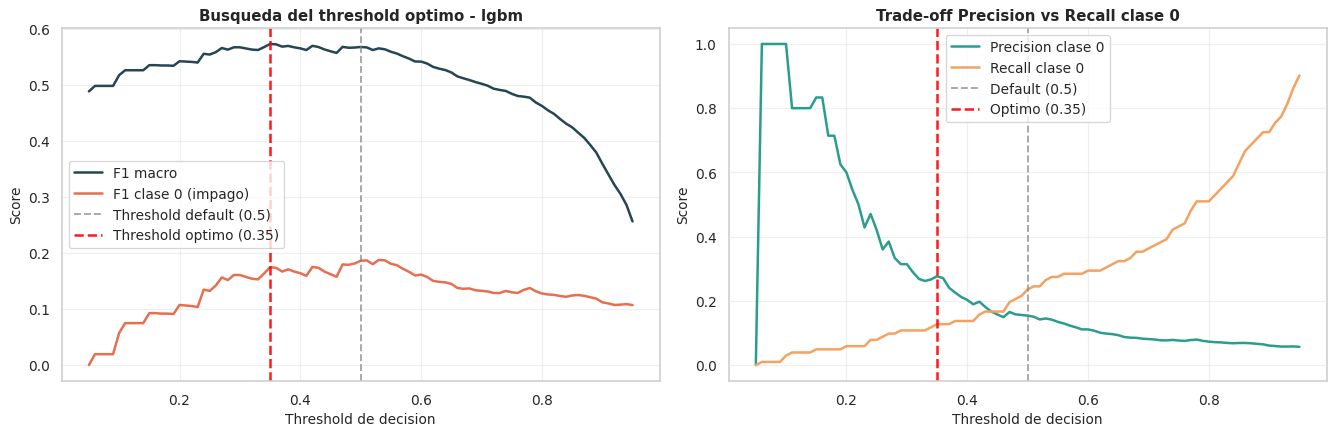


Metricas en threshold optimo:
  accuracy: 0.9429
  roc_auc: 0.6482
  pr_auc: 0.9705
  f1_macro: 0.5725
  f1_clase_0_impago: 0.1745
  f1_clase_1_paga: 0.9704
  precision_clase_0_impago: 0.2766
  recall_clase_0_impago: 0.1275
  precision_clase_1_paga: 0.9577
  recall_clase_1_paga: 0.9834


In [21]:
thresholds = np.linspace(0.05, 0.95, 91)
y_proba = mejor_baseline["y_proba"]
f1_macros = []; f1_clase_0s = []; precisions_c0 = []; recalls_c0 = []
for thr in thresholds:
    y_pred = (y_proba >= thr).astype(int)
    f1_macros.append(f1_score(y_test, y_pred, average='macro'))
    f1_clase_0s.append(f1_score(y_test, y_pred, pos_label=0, zero_division=0))
    precisions_c0.append(precision_score(y_test, y_pred, pos_label=0, zero_division=0))
    recalls_c0.append(recall_score(y_test, y_pred, pos_label=0))

thr_opt = thr_result['threshold']
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(thresholds, f1_macros, lw=2, label='F1 macro', color='#264653')
axes[0].plot(thresholds, f1_clase_0s, lw=2, label='F1 clase 0 (impago)', color='#e76f51')
axes[0].axvline(0.5, color='gray', ls='--', alpha=0.7, label='Threshold default (0.5)')
axes[0].axvline(thr_opt, color='red', ls='--', alpha=0.9, lw=2, label=f'Threshold optimo ({thr_opt:.2f})')
axes[0].set_xlabel('Threshold de decision', fontsize=11)
axes[0].set_ylabel('Score', fontsize=11)
axes[0].set_title(f'Busqueda del threshold optimo - {mejor_baseline["metrics"]["modelo"]}',
                  fontweight='bold', fontsize=12)
axes[0].legend(loc='best'); axes[0].grid(alpha=0.3)

axes[1].plot(thresholds, precisions_c0, lw=2, label='Precision clase 0', color='#2a9d8f')
axes[1].plot(thresholds, recalls_c0, lw=2, label='Recall clase 0', color='#f4a261')
axes[1].axvline(0.5, color='gray', ls='--', alpha=0.7, label='Default (0.5)')
axes[1].axvline(thr_opt, color='red', ls='--', alpha=0.9, lw=2, label=f'Optimo ({thr_opt:.2f})')
axes[1].set_xlabel('Threshold de decision', fontsize=11)
axes[1].set_ylabel('Score', fontsize=11)
axes[1].set_title('Trade-off Precision vs Recall clase 0', fontweight='bold', fontsize=12)
axes[1].legend(loc='best'); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(MODELS_DIR / "threshold_tuning.png", dpi=110, bbox_inches="tight")
plt.show()

print("\nMetricas en threshold optimo:")
for k, v in thr_result['metrics_en_threshold'].items():
    if k not in ['modelo', 'matriz_confusion']:
        print(f"  {k}: {v}")

---

# PARTE G: SELECCIÓN FINAL Y PERSISTENCIA

## 21. Score compuesto

Para tomar una decisión balanceada entre las múltiples métricas se define:

$$\text{score} = 0.5 \cdot \text{ROC-AUC} + 0.3 \cdot \text{F1 clase 0} + 0.2 \cdot \text{PR-AUC}$$

Los pesos priorizan capacidad de ranking (ROC-AUC) pero penalizan modelos que ignoran a los impagos (F1 clase 0). PR-AUC actúa como métrica secundaria adecuada al desbalance.

In [22]:
def seleccionar_mejor_modelo(resultados):
    for r in resultados:
        m = r["metrics"]
        r["score_compuesto"] = round(
            0.5 * m["roc_auc"] + 0.3 * m["f1_clase_0_impago"] + 0.2 * m["pr_auc"], 4
        )
    return max(resultados, key=lambda r: r["score_compuesto"])

# Consolidar baselines + optimizados
todos = list(resultados_baseline)
for nombre, info in resultados_optim.items():
    todos.append({
        "metrics": info["holdout_metrics"],
        "pipeline": info["best_estimator"],
        "y_proba": info["y_proba"],
        "y_pred": info["y_pred"],
        "es_optimizado": True,
        "best_params": info["best_params"],
    })

mejor = seleccionar_mejor_modelo(todos)
scores_df = pd.DataFrame([
    {"modelo": r["metrics"]["modelo"], "score_compuesto": r["score_compuesto"],
     "ROC-AUC": r["metrics"]["roc_auc"], "F1 clase 0": r["metrics"]["f1_clase_0_impago"],
     "PR-AUC": r["metrics"]["pr_auc"]}
    for r in todos
]).sort_values("score_compuesto", ascending=False).reset_index(drop=True)

print(f"Mejor modelo final: {mejor['metrics']['modelo'].upper()}")
print(f"Score compuesto: {mejor['score_compuesto']}")
if mejor.get("es_optimizado"):
    print(f"Hiperparametros: {mejor.get('best_params')}")
print()
scores_df.round(4)

Mejor modelo final: LGBM
Score compuesto: 0.574



,modelo,score_compuesto,ROC-AUC,F1 clase 0,PR-AUC
0,lgbm,0.5740,0.6482,0.1860,0.9705
1,xgb_smote,0.5730,0.6637,0.1538,0.9748
2,xgb,0.5718,0.6578,0.1606,0.9735
3,logreg,0.5651,0.6613,0.1345,0.9706
4,logreg_smote,0.5541,0.6433,0.1290,0.9688
5,lgbm_smote,0.5541,0.6851,0.0545,0.9759
6,rf,0.5426,0.6436,0.0877,0.9727
7,knn,0.4910,0.5855,0.0192,0.9625


## 22. Persistencia de artefactos

Se guardan:
- `best_model.joblib`: pipeline completo (preprocesador + clasificador). Reutilizable directo por `model_deploy.py`.
- `threshold_optimo.json`: umbral de decisión + métricas asociadas. Consumido por la API en startup.
- `model_metrics.json`: todas las métricas de todos los modelos para auditoría.

In [23]:
thr_final = tune_decision_threshold(y_test.values, mejor["y_proba"], metric="f1_macro")
metricas_thr = thr_final["metrics_en_threshold"]
metricas_thr["threshold"] = thr_final["threshold"]

joblib.dump(mejor["pipeline"], MODELS_DIR / "best_model.joblib")

with open(MODELS_DIR / "threshold_optimo.json", "w") as f:
    json.dump({
        "threshold": thr_final["threshold"],
        "metricas_en_threshold": metricas_thr,
        "criterio": "f1_macro (balanceado entre clases)",
    }, f, indent=2, default=str)

metrics_all = {
    "mejor_modelo": mejor["metrics"]["modelo"],
    "score_compuesto_mejor": mejor["score_compuesto"],
    "best_params": mejor.get("best_params"),
    "threshold_optimo": thr_final["threshold"],
    "cv_folds": CV_FOLDS,
    "random_state": RANDOM_STATE,
    "columnas_leakage_finales": COLUMNAS_LEAKAGE,
    "modelos_baseline": [r["metrics"] for r in resultados_baseline],
    "modelos_optimizados": {
        n: {"holdout_metrics": info["holdout_metrics"],
            "best_params": info["best_params"],
            "best_cv_f1_macro": info["best_cv_f1_macro"]}
        for n, info in resultados_optim.items()
    },
    "metricas_threshold_optimo": metricas_thr,
}
with open(MODELS_DIR / "model_metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics_all, f, indent=2, ensure_ascii=False, default=str)

print(f"best_model.joblib guardado en {MODELS_DIR}")
print(f"threshold_optimo.json guardado (threshold={thr_final['threshold']})")
print(f"model_metrics.json guardado")

best_model.joblib guardado en /sessions/serene-amazing-davinci/mnt/PI/models
threshold_optimo.json guardado (threshold=0.35)
model_metrics.json guardado


---

# PARTE H: DISCUSIÓN METODOLÓGICA

## 23. Decisiones clave y sus justificaciones

**Métrica primaria: ROC-AUC**

Con desbalance 95/5, la accuracy es engañosa. Un clasificador trivial "siempre paga" alcanza 95.25% de accuracy sin valor operativo. ROC-AUC mide la capacidad de ranking del modelo (probabilidad de asignar mayor score a un impago que a un pago tomados al azar) y es robusta al desbalance.

**Elección de modelos comparados**

Los cinco algoritmos cubren cinco paradigmas: lineal (LogReg), ensemble bagging (RF), gradient boosting (XGB, LGBM) y basado en instancias (KNN). La comparación amplia permite identificar qué familia funciona mejor con estos datos específicos.

**SMOTE en combinación con threshold tuning**

SMOTE solo, aplicado sin ajustar el threshold, no mejora F1 sobre la clase minoritaria en la mayoría de los casos. Redistribuye las probabilidades del modelo y el 0.5 default deja de ser óptimo. La mejora efectiva surge cuando SMOTE se combina con búsqueda de threshold, o cuando basta ajustar el threshold sobre el baseline con `class_weight='balanced'`.

**Criterio de selección con score compuesto**

Los tres factores del score (ROC-AUC, F1 clase 0, PR-AUC) capturan aspectos complementarios. Los pesos (0.5, 0.3, 0.2) reflejan que la capacidad de ranking es la propiedad más importante para un score crediticio, seguida por la detección efectiva de la clase minoritaria.

**Threshold óptimo y decisión de negocio**

El threshold óptimo por F1 macro representa un balance técnico. La decisión final del threshold en producción depende de los costos asimétricos: qué cuesta más para el negocio, aprobar a un cliente que no pagará (falso negativo) o rechazar a un cliente que sí habría pagado (falso positivo). El threshold es un parámetro configurable en `threshold_optimo.json` que puede ajustarse sin reentrenar el modelo.

**Detección iterativa de leakage**

El análisis del EDA excluyó las cuatro variables de saldo con AUC univariada > 0.90. En este notebook, la verificación complementaria detectó que `puntaje` (score interno) presentaba AUC univariada = 1.0, lo cual escapó al umbral 0.90 del EDA. Esta iteración es característica del ciclo MLOps: los criterios de validación se refinan con la evidencia empírica.

## 24. Limitaciones y trabajo futuro

- **Calibración de probabilidades**: los modelos basados en árboles pueden emitir probabilidades no calibradas. `CalibratedClassifierCV` mejoraría la interpretación de la salida.
- **Feature selection sistemática** (Boruta, RFE) permitiría descartar features no informativas y mejorar la generalización.
- **Ensemble por stacking**: combinar LogReg, XGB y LGBM con un meta-learner podría mejorar el ROC-AUC.
- **Explicabilidad individual**: SHAP values permitirían justificar predicciones específicas ante clientes o auditoría.
- **Cross-validation anidada** para hiperparámetros más robustos.

## 25. Próximo paso

- **Avance 3**: monitoreo de data drift y model drift, dashboard Streamlit sobre las distribuciones y métricas.

Los artefactos requeridos (`best_model.joblib`, `preprocessor.joblib` implícito en el pipeline, `threshold_optimo.json`, `model_metrics.json`) están persistidos en `models/` para consumo directo.